In [66]:
Plan:
# 1. Load dataset ✅
# 2. Inspect columns ✅
# 3. Dataset shape ✅
# 4. Missing values ✅
# 5. Duplicate protein IDs ✅
# 6. Duplicate sequences ✅
# 7. Sequence alphabet validation ✅
# 8. Length distribution ✅
# 9. Activity distribution
# 10. Multi-label records
# 11. Save QC report

SyntaxError: invalid syntax (3085144363.py, line 1)

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/gh13_candidates.csv")

df.head()

,protein_id,protein_name,organism,gh_family,ec_number,activity,subfamily,length,sequence,source,md5
0,Q8GTR4,pullulanase / isoamylase (LDA;AtPU1;AtLDA;LDA1...,Arabidopsis thaliana,GH13,3.2.1.41;3.2.1.68,pullulanase;isoamylase,13,965,MALTLTPTSSVHLLSSISVARPRIFAADFNLRSRWRRRRPVTSISN...,CAZy;UniProt,0F48A37B677FE6B07105A2A1C0E5CF3C
1,Q8VZ56,alpha-amylase (AtAmy1;At4g25000) (apoplast),Arabidopsis thaliana,GH13,3.2.1.1,alpha-amylase,6,423,MTSLHTLLFSSLLFFIVFPTFTFSSTLLFQSFNWESWKKEGGFYNS...,CAZy;UniProt,B7442155A66F3BC3DAF0DD8982EDAD42
2,A0A178VW25,At2g39930 (chloroplastic isoamylase 2;AtISA1;I...,Arabidopsis thaliana,GH13,3.2.1.68,isoamylase,11,783,MDAIKCSSSFLHHTKLNTLFSNHTFPKISAPNFKPLFRPISISAKD...,CAZy;UniProt,ED774D756A77980210D2D32E20DDD5AC
3,Q9M0S5,chloroplastic isoamylase 3 (Isa3;AtISA3;At4g09...,Arabidopsis thaliana,GH13,3.2.1.68,isoamylase,11,764,MLTSPSSSSTYDPFSSNFSPSLTNAFSSSFTIPMGLKLSRRVTRAR...,CAZy;UniProt,39675D5C27934A33AFBEEECBDD4D81B1


In [2]:
df.shape

(4, 11)

In [3]:
df.columns.tolist()

['protein_id',
 'protein_name',
 'organism',
 'gh_family',
 'ec_number',
 'activity',
 'subfamily',
 'length',
 'sequence',
 'source',
 'md5']

In [4]:
df.isna().sum()

protein_id      0
protein_name    0
organism        0
gh_family       0
ec_number       0
activity        0
subfamily       0
length          0
sequence        0
source          0
md5             0
dtype: int64

In [5]:
df["activity"].value_counts()

activity
isoamylase                2
pullulanase;isoamylase    1
alpha-amylase             1
Name: count, dtype: int64

In [6]:
len(df["protein_id"].unique())

4

In [7]:
len(df["protein_id"]) == len(df["protein_id"].unique())

True

In [8]:
len(df["sequence"]) == len(df["sequence"].unique())

True

In [9]:
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

def invalid_chars(sequence):
    return set(sequence) - VALID_AA


In [10]:
df["invalid_chars"] = df["sequence"].apply(invalid_chars)
df["invalid_chars"]

0    {}
1    {}
2    {}
3    {}
Name: invalid_chars, dtype: object

In [11]:
# 8. Length distribution
seq_len = len(df["length"])
seq_min = df["length"].min
seq_max = df["length"].max
seq_mean = df["length"].mean
seq_median = df["length"].median

seq_quantile25 = df["length"].quantile(0.25)
seq_quantile50 = df["length"].quantile(0.50)
seq_quantile75 = df["length"].quantile(0.75)
seq_IQR = seq_quantile75 - seq_quantile25

seq_std = df["length"].std()

seq_len, seq_min, seq_max, seq_mean, seq_median, seq_quantile25, seq_quantile50, seq_quantile75, seq_IQR, seq_std

(4,
 <bound method Series.min of 0    965
 1    423
 2    783
 3    764
 Name: length, dtype: int64>,
 <bound method Series.max of 0    965
 1    423
 2    783
 3    764
 Name: length, dtype: int64>,
 <bound method Series.mean of 0    965
 1    423
 2    783
 3    764
 Name: length, dtype: int64>,
 <bound method Series.median of 0    965
 1    423
 2    783
 3    764
 Name: length, dtype: int64>,
 np.float64(678.75),
 np.float64(773.5),
 np.float64(828.5),
 np.float64(149.75),
 np.float64(226.11409361942333))

In [12]:
import matplotlib.pyplot as plt


In [13]:
df["length"]

0    965
1    423
2    783
3    764
Name: length, dtype: int64

In [14]:
len(df["sequence"][0])

965

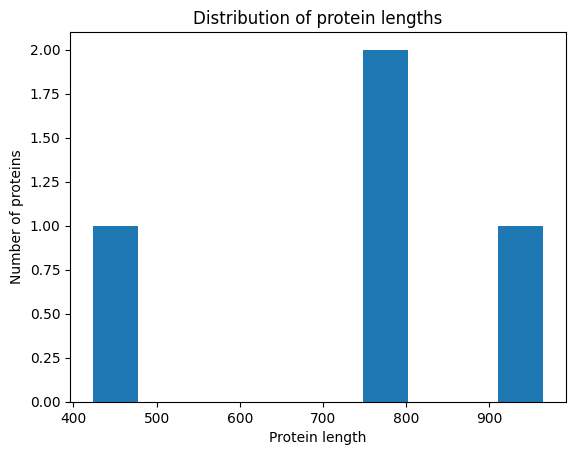

In [15]:
plt.hist(df["length"])
plt.xlabel("Protein length")
plt.ylabel("Number of proteins")
plt.title("Distribution of protein lengths")
plt.show()

In [16]:
df["sequence"].value_counts()

sequence
MALTLTPTSSVHLLSSISVARPRIFAADFNLRSRWRRRRPVTSISNFRLRLPSKTSLHCLCSSSSASSPMSLEVSSPNSQFLDCLIYSRAYWVTQGVIAWNVDVGEGSCYFYASKSAGLSFSEDGIDGYDLRIKLEAESGSLPADVIEKFPHIRNYKSFKVPKDLDIRDLVKSQLAVVCFDAEGRLIQGTGLQLPGVLDELFSYDGPLGAHFTPEGVSLHLWAPTAQAVSVCIYKNPLDKSPMEICPLKEANGVWSTEGACSWGGCYYVYKVSVYHPSTMKLETCYANDPYARGLSADGRKTFLVNLDSDDLKPEGWDNLADKKPCLRSFSDISIYELHVRDFSANDETVEPENRGGYLAFTSKDSAGVKHLQKLVDAGLTHLHLLPTFQFGDVDDEKENWKSVDTSLLEGLRPDSTEAQARITEIQNDDGYNWGYNPVLWGVPKGSYASDPTGPCRIIEFRKMVQALNCTGLNVVLDVVYNHLHASGPHDKESVLDKIVPGYYLRRNSDGFIENSTCVNNTASEHYMVDRLIRDDLLNWVVNYKVDGFRFDLMGHIMKATIVNAKSAIGSLRKETDGVDGSRIYLYGEGWNFGEVAENGRGINASQFNLGGTGIGSFNDRIRDATLGGSPFGHPLQQGFITGLLLQPNAHDHGSEATQELMLSTAKNHIQTGMAANLKDYMLTNHEGKEVKGSEVLMHDATPVAYASLPTETINYVSAHDNETLFDIISLKTPMEISVDERCRINHLASSMIALSQGIPFFHAGDEILRSKSLDRDSYNSGDWFNRLDFSYSSNNWGVGLPPKGKNEHNWPLIKPRLQDPSFKPKSSHIVATLHNFLDLLRIRYSSPLFRLDTARAIQERVRFHNTGPSSIPGAIVMSIEDGHRGIPSVSQIDPIYSLIVVIFNARPSEFSYPSPALKDRKLELHPVQVMSADEIVKKSVYDSFSGGFTVPARTTTVFVESRNG    1
MTSLHTLLFSSLLFFIVFPT

In [17]:
activities_count = df["activity"].value_counts()
activities_count.index

Index(['isoamylase', 'pullulanase;isoamylase', 'alpha-amylase'], dtype='object', name='activity')

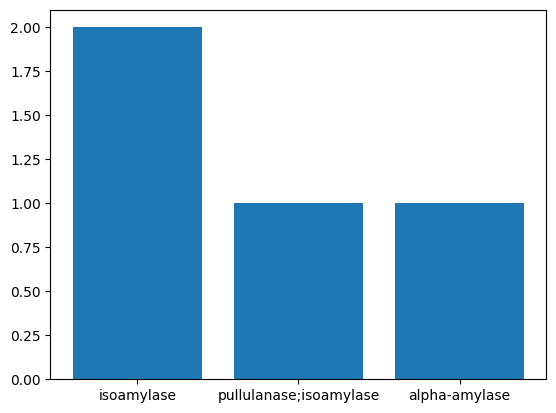

In [18]:
activities_count = df["activity"].value_counts()
plt.bar(activities_count.index, activities_count.values, width=0.8, align='center', label="Distribution of protein activities")
plt.show()

In [19]:
df["activity"].str.split(';',expand=True)

,0,1
0,pullulanase,isoamylase
1,alpha-amylase,None
2,isoamylase,None
3,isoamylase,None


In [20]:
df["activity"]

0    pullulanase;isoamylase
1             alpha-amylase
2                isoamylase
3                isoamylase
Name: activity, dtype: object

In [21]:
df[df["activity"].str.contains(";")]

,protein_id,protein_name,organism,gh_family,ec_number,activity,subfamily,length,sequence,source,md5,invalid_chars
0,Q8GTR4,pullulanase / isoamylase (LDA;AtPU1;AtLDA;LDA1...,Arabidopsis thaliana,GH13,3.2.1.41;3.2.1.68,pullulanase;isoamylase,13,965,MALTLTPTSSVHLLSSISVARPRIFAADFNLRSRWRRRRPVTSISN...,CAZy;UniProt,0F48A37B677FE6B07105A2A1C0E5CF3C,{}


In [49]:
import json
qc_report = {
    "len": seq_len, 
    "seq_min": seq_min(), 
    "seq_max":seq_max(), 
    "seq_mean":seq_mean(), 
    "seq_median":seq_median(), 
    "seq_quantile25":seq_quantile25, 
    "seq_quantile75":seq_quantile75, 
    "seq_IQR":seq_IQR, 
    "seq_std":seq_std,
    "na_values_count":(df.isna().sum()).to_dict(), 
    "unique_values_count":len(df["protein_id"].unique())
}
qc_report

{'len': 4,
 'seq_min': np.int64(423),
 'seq_max': np.int64(965),
 'seq_mean': np.float64(733.75),
 'seq_median': np.float64(773.5),
 'seq_quantile25': np.float64(678.75),
 'seq_quantile75': np.float64(828.5),
 'seq_IQR': np.float64(149.75),
 'seq_std': np.float64(226.11409361942333),
 'na_values_count': {'protein_id': 0,
  'protein_name': 0,
  'organism': 0,
  'gh_family': 0,
  'ec_number': 0,
  'activity': 0,
  'subfamily': 0,
  'length': 0,
  'sequence': 0,
  'source': 0,
  'md5': 0,
  'invalid_chars': 0},
 'unique_values_count': 4}

In [51]:
data = json.dumps(qc_report, default=str,indent=2)

In [53]:
with open('../data/processed/qc_report.json', 'w') as f:
    json.dump(data, f)

In [54]:
len(df["md5"]) == len(df["md5"].unique())

True